# Lab: Principal Component Analysis (PCA)
### Student Notebook

Your name: Raghavendra Prasad G Shetti

## Instructions
- This notebook has **5 parts**.
- Every cell has instructions as comments (`# ...`). Follow them carefully.
- Some cells have **blanks to fill in** marked with `___`. Replace each `___` with the correct code.
- Do **not** change the structure of the functions - only fill in the missing parts.
- Run each cell after completing it to check your output.

Datasets: Iris, Wine, Digits (all built-in sklearn, no files needed)

PCA is unsupervised. Class labels are never used to fit PCA.
They are only used to colour plots afterwards.

Section 1 (Iris) has fewer blanks -- focus on reading and understanding each step.
Section 2 (Wine) has more blanks -- apply the same steps independently.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_wine, load_digits
from sklearn.preprocessing import StandardScaler

# TODO: import PCA from sklearn.decomposition
from sklearn.decomposition import PCA

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
print("Imports done")

Imports done


---
## Section 1 -- Iris: Before and After PCA

Iris has 4 numeric features: sepal length, sepal width, petal length, petal width.

We cannot plot all 4 dimensions at once. PCA answers: what is the single best 2D view of this 4-dimensional data?

Note on why we use Iris here: Iris is a clean teaching dataset. Some feature pairs already separate the classes well. We use it to understand PCA mechanics in a familiar setting. Section 2 (Wine) is where you will do more of the coding yourself.

This section has fewer blanks. Read every comment and understand what each cell does before moving to Section 2.

In [2]:
# Load the Iris dataset.
# iris.data is a numpy array of shape (150, 4).
# Wrap it in a DataFrame using iris.feature_names as column names.
iris = load_iris()

# TODO: Create a DataFrame from iris.data with iris.feature_names as columns
X_iris = pd.DataFrame(data= iris.data, columns=iris.feature_names)
y_iris = iris.target  # 0=setosa, 1=versicolor, 2=virginica

print("Feature matrix shape:", X_iris.shape)
print("Class labels:", iris.target_names)
X_iris.head()

Feature matrix shape: (150, 4)
Class labels: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [9]:
# Explore the data before running PCA.
# describe() shows count, mean, std, min, quartiles, max for each column.
# Notice the different value ranges across features -- this is why we scale.

# TODO: Print summary statistics for X_iris
print(X_iris.round(2))
print(X_iris.describe())

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]
       sepal length (cm)  sepal width (c

In [4]:
# Check how many samples belong to each species.
# value_counts() on a Series returns the count of each unique value.
import pandas as pd
pd.Series(y_iris).value_counts().rename({0:"setosa", 1:"versicolor", 2:"virginica"})

setosa        50
versicolor    50
virginica     50
dtype: int64

In [5]:
# Scale the data before PCA.
# StandardScaler makes every feature have mean=0 and std=1.
# This prevents features with large ranges from dominating the variance.
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

# Fit PCA with no n_components argument to keep all 4 components first.
# We will inspect all of them before deciding how many to keep.
pca_iris = PCA()

# TODO: Fit PCA on X_iris_scaled and transform it. Store result in X_iris_pca.
# Hint: use fit_transform()
X_iris_pca = pca_iris.fit_transform(X_iris_scaled)

print("Original shape:  ", X_iris.shape)
print("PCA output shape:", X_iris_pca.shape)

Original shape:   (150, 4)
PCA output shape: (150, 4)


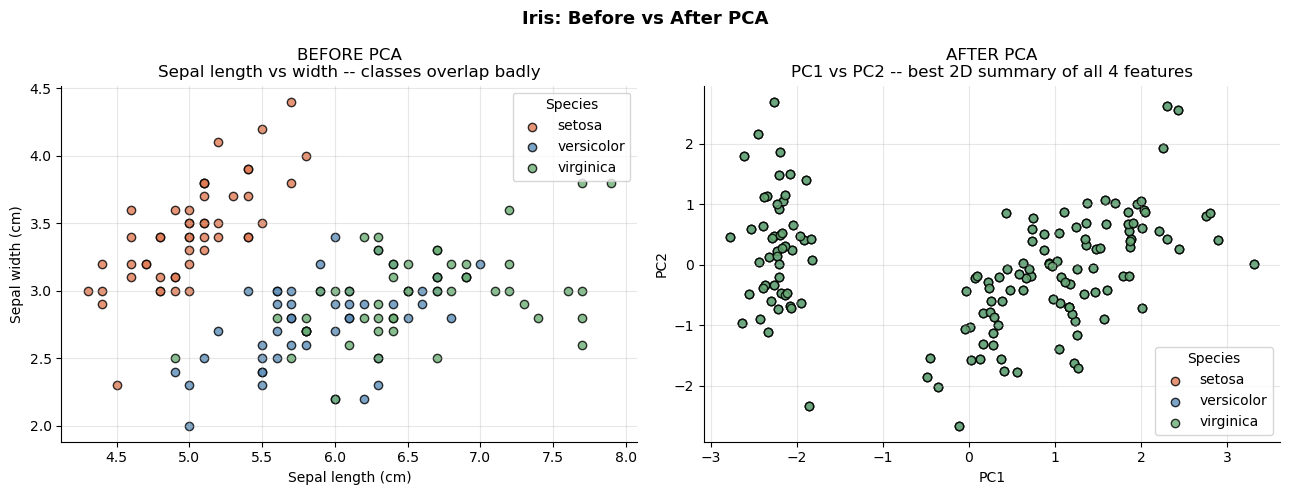

In [6]:
# Side-by-side plot: original features vs PCA projection.
# LEFT: sepal length vs sepal width -- classes overlap here.
# RIGHT: PC1 vs PC2 -- PCA found this automatically without seeing class labels.

colors = ["#E07B54", "#5B8DB8", "#6BAE75"]
class_names = iris.target_names

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left plot -- pre-filled
for cid, cname in enumerate(class_names):
    mask = y_iris == cid
    axes[0].scatter(X_iris.iloc[mask, 0], X_iris.iloc[mask, 1],
                    color=colors[cid], label=cname, edgecolor="k", alpha=0.8)
axes[0].set_xlabel("Sepal length (cm)")
axes[0].set_ylabel("Sepal width (cm)")
axes[0].set_title("BEFORE PCA\nSepal length vs width -- classes overlap badly")
axes[0].legend(title="Species")
axes[0].grid(True, alpha=0.3)

# TODO: Right plot -- PC1 vs PC2
# Same loop structure as the left plot.
# Use X_iris_pca[:, 0] for x and X_iris_pca[:, 1] for y.
for cid, cname in enumerate(class_names):
    mask = y_iris == cid
    axes[1].scatter(X_iris_pca[:, 0], X_iris_pca[:, 1],
                    color=colors[cid], label=cname, edgecolor="k", alpha=0.8)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("AFTER PCA\nPC1 vs PC2 -- best 2D summary of all 4 features")
axes[1].legend(title="Species")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Iris: Before vs After PCA", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Component  Variance explained  Cumulative variance
      PC1            0.729624             0.729624
      PC2            0.228508             0.958132
      PC3            0.036689             0.994821
      PC4            0.005179             1.000000


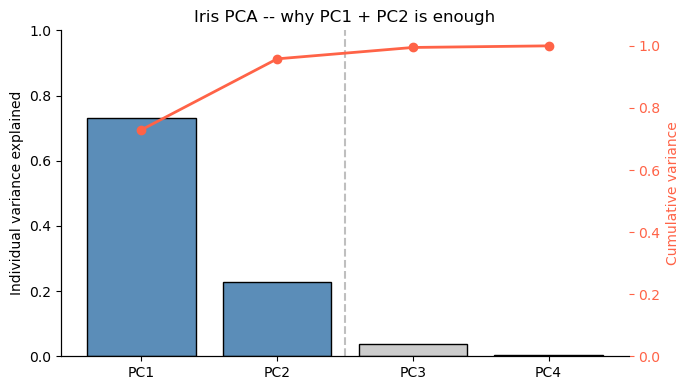

PC1 + PC2 preserve 95.8% of variance.
PC3 + PC4 add only  4.2% more.


In [11]:
# Variance table: how much does each PC contribute?
# explained_variance_ratio_ is an attribute on the fitted PCA object.
# np.cumsum() computes the running total across components.
var_ratio = pca_iris.explained_variance_ratio_
cumvar    = np.cumsum(var_ratio)

# TODO: Fill in the two missing values in the DataFrame
var_df = pd.DataFrame({
    "Component": ["PC1", "PC2", "PC3", "PC4"],
    "Variance explained": var_ratio,      # use var_ratio
    "Cumulative variance": cumvar     # use cumvar
})
print(var_df.to_string(index=False))

# Bar chart -- pre-filled so you can focus on reading it.
# Blue bars = components we keep, grey bars = components we drop.
# Red line = cumulative variance. Dashed line = the cut point.
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.bar(["PC1", "PC2", "PC3", "PC4"], var_ratio,
        color=["#5B8DB8","#5B8DB8","#CCCCCC","#CCCCCC"], edgecolor="k")
ax1.set_ylabel("Individual variance explained")
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
ax2.plot(["PC1", "PC2", "PC3", "PC4"], cumvar,
         color="tomato", marker="o", linewidth=2)
ax2.set_ylabel("Cumulative variance", color="tomato")
ax2.set_ylim(0, 1.05)
ax2.tick_params(axis="y", colors="tomato")

ax1.set_title("Iris PCA -- why PC1 + PC2 is enough")
ax1.axvline(1.5, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# TODO: Complete these two print statements using cumvar
print(f"PC1 + PC2 preserve {cumvar[1]:.1%} of variance.")
print(f"PC3 + PC4 add only  {cumvar[3]-cumvar[1]:.1%} more.")

---
## Section 2 -- Wine: Why PCA, and How Many Components?

Wine has 13 numeric features. No one can inspect a 13-dimensional dataset by eye.

This section has more blanks than Section 1. Apply the same steps you saw in Iris, now independently on Wine.

Two questions to answer through code:
1. Why use PCA at all? Show that PC1 vs PC2 reveals class structure that original feature pairs hide.
2. How many components to keep? Use the cumulative curve and elbow bar chart to make that decision.

In [13]:
# Load the Wine dataset. Same pattern as Iris in Section 1.
# 178 samples, 13 features, 3 wine classes.
wine = load_wine()

# TODO: Create a DataFrame from wine.data using wine.feature_names as columns
X_wine = pd.DataFrame(data = wine.data, columns=wine.feature_names)
y_wine = wine.target

# TODO: Show the shape of wine features (X) and first 3 rows
print("Feature matrix shape:",X_wine.shape)
print("Class names:", wine.target_names)
X_wine.head(3)

Feature matrix shape:      alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0      14.23        1.71  2.43               15.6      127.0           2.80   
1      13.20        1.78  2.14               11.2      100.0           2.65   
2      13.16        2.36  2.67               18.6      101.0           2.80   
3      14.37        1.95  2.50               16.8      113.0           3.85   
4      13.24        2.59  2.87               21.0      118.0           2.80   
..       ...         ...   ...                ...        ...            ...   
173    13.71        5.65  2.45               20.5       95.0           1.68   
174    13.40        3.91  2.48               23.0      102.0           1.80   
175    13.27        4.28  2.26               20.0      120.0           1.59   
176    13.17        2.59  2.37               20.0      120.0           1.65   
177    14.13        4.10  2.74               24.5       96.0           2.05   

     flavanoids  nonflavanoid

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0


In [15]:
# Explore the Wine data before running PCA.
# With 13 features, describe() is important. Look at the different scales.
# Features with large ranges will dominate PCA unless we scale first.

# TODO: Print summary statistics for X_wine
print(X_wine.round(2))
X_wine.describe()

     alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0      14.23        1.71  2.43               15.6      127.0           2.80   
1      13.20        1.78  2.14               11.2      100.0           2.65   
2      13.16        2.36  2.67               18.6      101.0           2.80   
3      14.37        1.95  2.50               16.8      113.0           3.85   
4      13.24        2.59  2.87               21.0      118.0           2.80   
..       ...         ...   ...                ...        ...            ...   
173    13.71        5.65  2.45               20.5       95.0           1.68   
174    13.40        3.91  2.48               23.0      102.0           1.80   
175    13.27        4.28  2.26               20.0      120.0           1.59   
176    13.17        2.59  2.37               20.0      120.0           1.65   
177    14.13        4.10  2.74               24.5       96.0           2.05   

     flavanoids  nonflavanoid_phenols  proanthocyan

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [19]:
# Check for missing values -- PCA cannot handle NaN values.
# Then check the class distribution.

# TODO: Print the count of missing values per column
print("Missing values per column:")
print(X_wine.isnull().sum())

# Check class balance
print("\nSamples per class:")
print(pd.Series(y_wine).value_counts().rename(
    {0:wine.target_names[0], 1:wine.target_names[1], 2:wine.target_names[2]}))

Missing values per column:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

Samples per class:
class_1    71
class_0    59
class_2    48
dtype: int64


In [20]:
# Scale Wine features and fit PCA with all 13 components.
# Same steps as Iris Section 1. Apply them independently here.

# TODO: Scale X_wine using StandardScaler
X_wine_scaled = StandardScaler().fit_transform(X_wine)

# TODO: Create a PCA object with no n_components argument (keep all)
pca_wine = PCA()

# TODO: Fit PCA and transform X_wine_scaled in one step
X_wine_pca = pca_wine.fit_transform(X_wine_scaled)

# These two lines compute the variance arrays -- pre-filled
wine_var    = pca_wine.explained_variance_ratio_
wine_cumvar = np.cumsum(wine_var)
n = X_wine.shape[1]

print(f"Total components available: {n}")
print(f"Variance captured by PC1+PC2: {wine_cumvar[1]:.1%}")

Total components available: 13
Variance captured by PC1+PC2: 55.4%


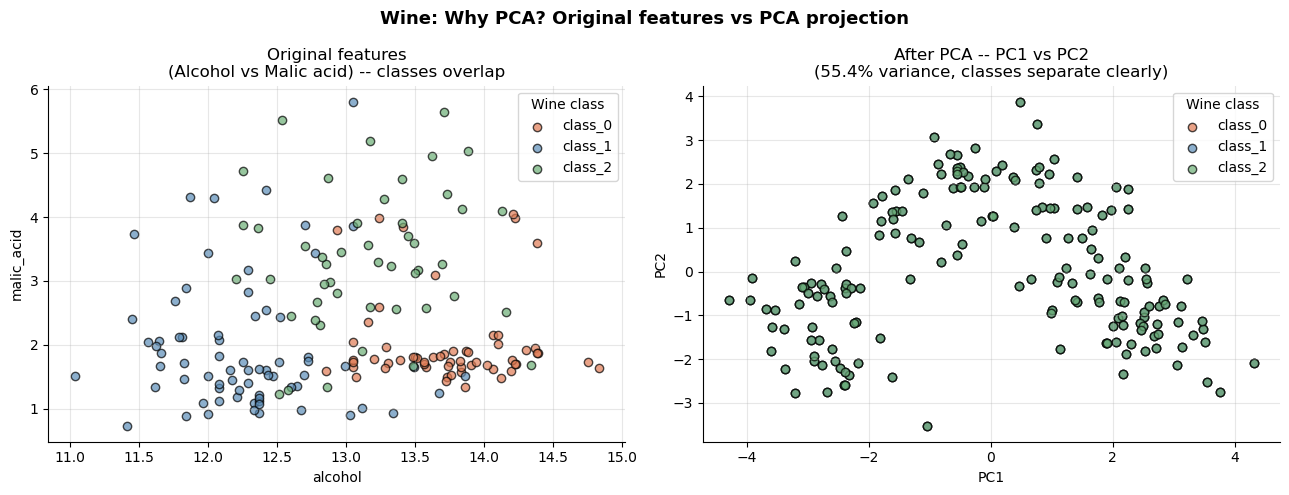

In [21]:
# Why use PCA at all on Wine?
# LEFT: original feature pair -- classes overlap.
# RIGHT: PC1 vs PC2 -- classes separate. Fill in the right plot.

colors_wine = ["#E07B54", "#5B8DB8", "#6BAE75"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: original feature pair -- pre-filled
for cid, cname in enumerate(wine.target_names):
    mask = y_wine == cid
    axes[0].scatter(X_wine.iloc[mask, 0], X_wine.iloc[mask, 1],
                    color=colors_wine[cid], label=cname, edgecolor="k", alpha=0.7)
axes[0].set_xlabel(wine.feature_names[0])
axes[0].set_ylabel(wine.feature_names[1])
axes[0].set_title("Original features\n(Alcohol vs Malic acid) -- classes overlap")
axes[0].legend(title="Wine class")
axes[0].grid(True, alpha=0.3)

# TODO: Right plot -- PC1 vs PC2
# Same loop as the left. Use X_wine_pca[:, 0] and X_wine_pca[:, 1].
for cid, cname in enumerate(wine.target_names):
    mask = y_wine == cid
    axes[1].scatter( X_wine_pca[:, 0], X_wine_pca[:, 1],
                    color=colors_wine[cid], label=cname, edgecolor="k", alpha=0.7)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title(f"After PCA -- PC1 vs PC2\n({wine_cumvar[1]:.1%} variance, classes separate clearly)")
axes[1].legend(title="Wine class")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Wine: Why PCA? Original features vs PCA projection", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

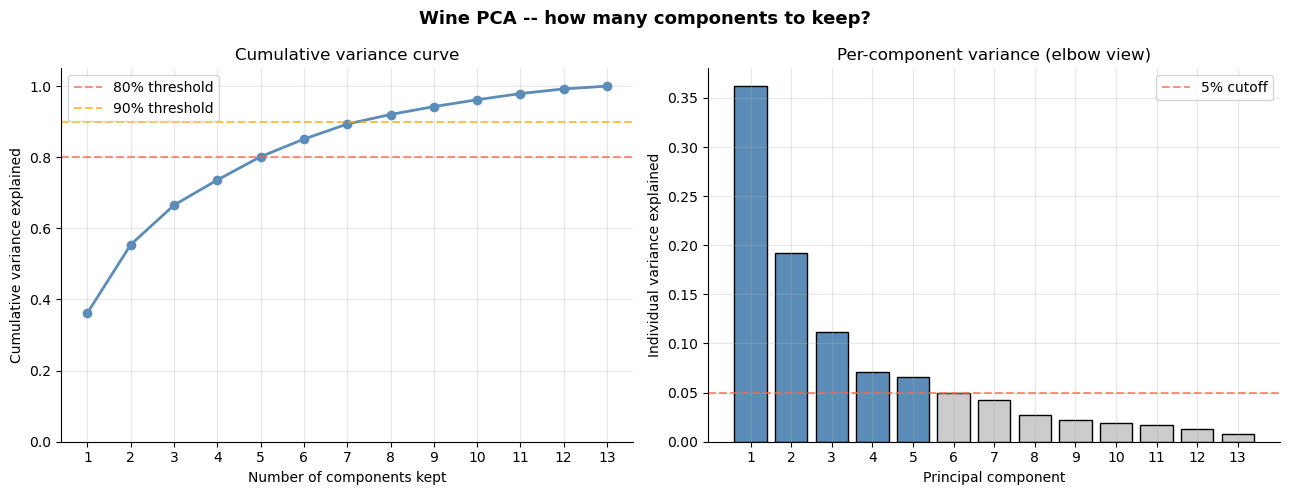

80% variance reached at 5 components
90% variance reached at 8 components


In [22]:
# How many components to keep for Wine?
# Plot the cumulative curve and the per-component bar chart side by side.
# Then find the exact component count at 80% and 90% variance thresholds.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
components = range(1, n + 1)

# Left: cumulative variance curve
# TODO: Plot wine_cumvar against components with marker="o"
axes[0].plot(components, wine_cumvar, marker="o", color="#5B8DB8", linewidth=2)
axes[0].axhline(0.80, color="tomato", linestyle="--", alpha=0.7, label="80% threshold")
axes[0].axhline(0.90, color="orange", linestyle="--", alpha=0.7, label="90% threshold")
axes[0].set_xlabel("Number of components kept")
axes[0].set_ylabel("Cumulative variance explained")
axes[0].set_title("Cumulative variance curve")
axes[0].set_xticks(list(components))
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: per-component bar chart
# Blue if the component explains more than 5%, grey if less.
bar_colors = ["#5B8DB8" if v > 0.05 else "#CCCCCC" for v in wine_var]
# TODO: Plot a bar chart of wine_var against components
axes[1].bar(components, wine_var, color=bar_colors, edgecolor="k")
axes[1].set_xlabel("Principal component")
axes[1].set_ylabel("Individual variance explained")
axes[1].set_title("Per-component variance (elbow view)")
axes[1].set_xticks(list(components))
axes[1].axhline(0.05, color="tomato", linestyle="--", alpha=0.7, label="5% cutoff")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Wine PCA -- how many components to keep?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# TODO: Find the number of components needed to reach 80% and 90% variance
for threshold in [0.80, 0.90]:
    k = next(i+1 for i, v in enumerate(wine_cumvar) if v >= threshold)
    print(f"{threshold:.0%} variance reached at {k} components")

---
## Section 3 -- Digits: Reconstruction and Information Loss

This is the reconstruction experiment from the lecture, using sklearn's built-in Digits dataset.
Each image is 8x8 pixels = 64 numeric features per sample.

The experiment: keep only d principal components, project down, then reverse-project back to 64 pixels.
Small d = heavy compression = blurry reconstruction. Large d = light compression = sharp reconstruction.

The grid shows all 10 digit classes (0 through 9) across several values of d.

Data shape (flattened): (1797, 64)
Image shape (2D): (8, 8)


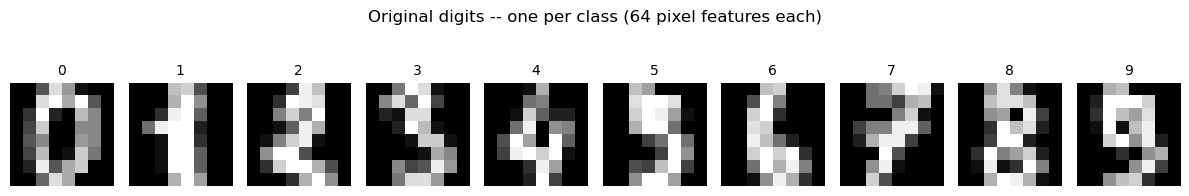

In [23]:
# Load the Digits dataset.
# digits.data:   shape (1797, 64) -- each row is one flattened 8x8 image.
# digits.images: shape (1797, 8, 8) -- same data as 2D images.
# digits.target: integer label 0 through 9.
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

print("Data shape (flattened):", X_digits.shape)
print("Image shape (2D):", digits.images[0].shape)

# Show one original image per digit class -- pre-filled
fig, axes = plt.subplots(1, 10, figsize=(12, 2))
for digit in range(10):
    idx = np.where(y_digits == digit)[0][0]
    axes[digit].imshow(digits.images[idx], cmap="gray")
    axes[digit].set_title(str(digit), fontsize=10)
    axes[digit].axis("off")
plt.suptitle("Original digits -- one per class (64 pixel features each)", y=1.05)
plt.tight_layout()
plt.show()

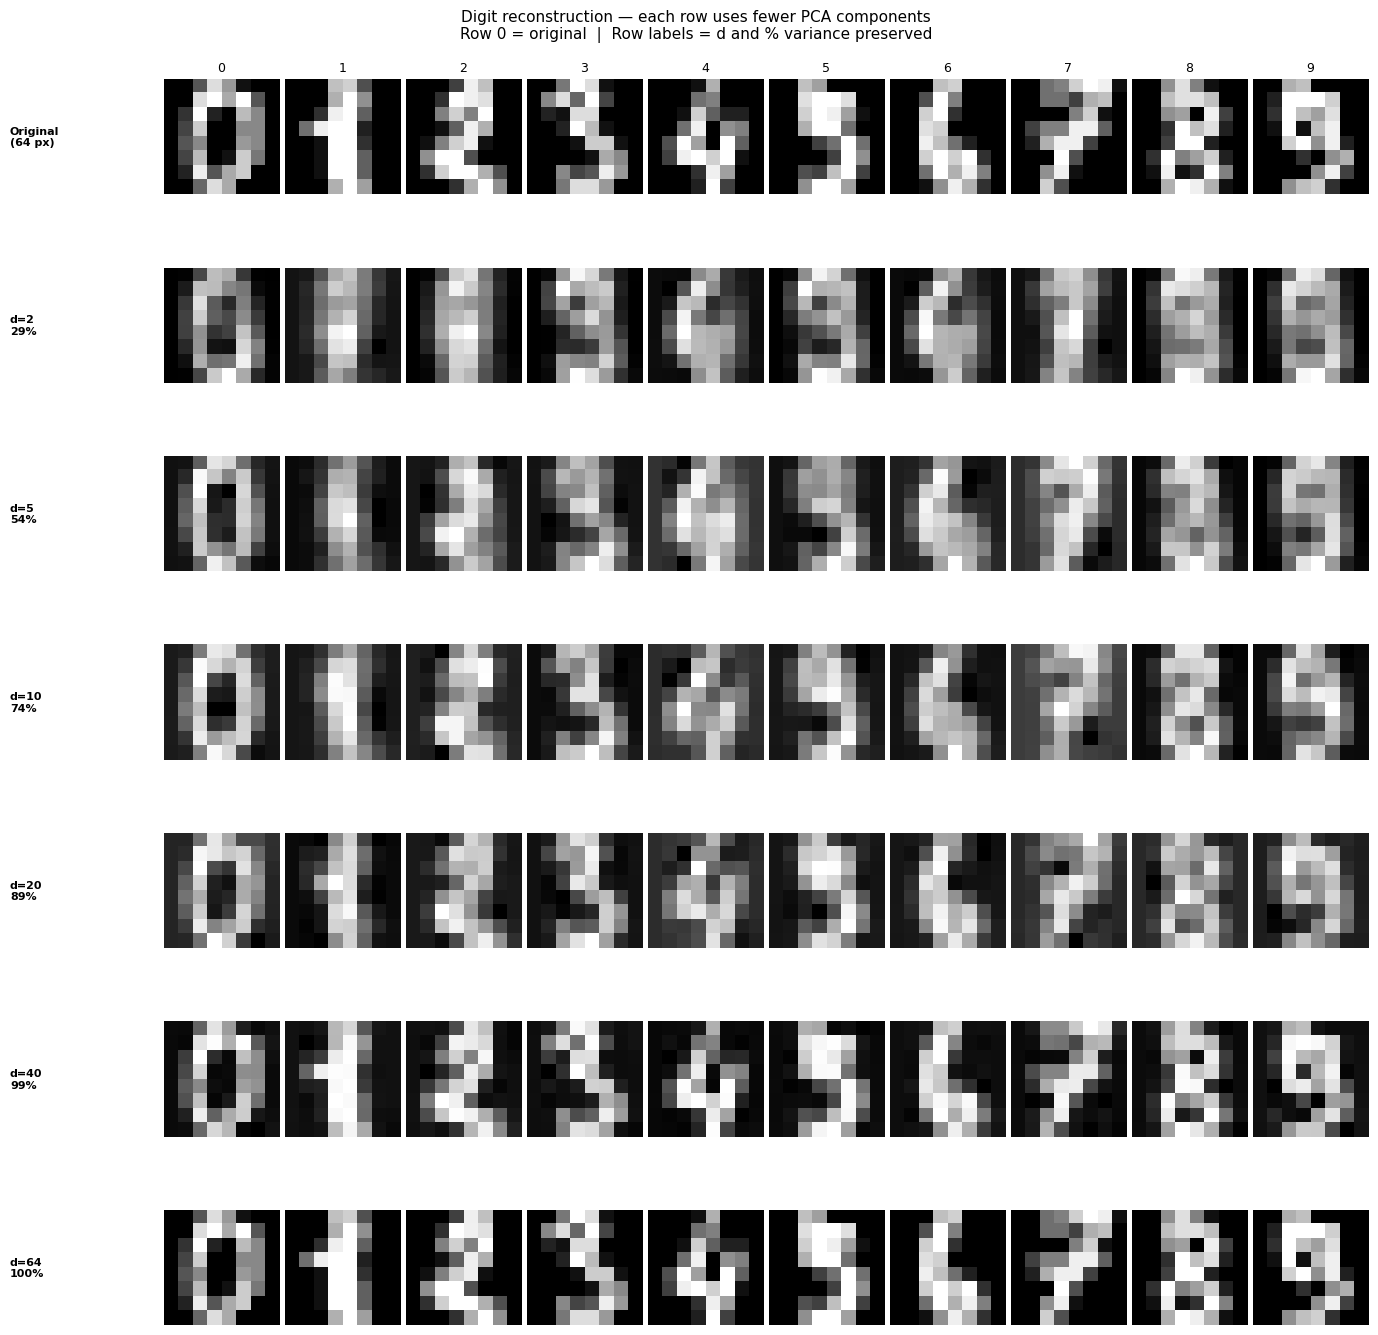

In [26]:
# Reconstruction grid.
# For each d, fit PCA, project down to d dimensions, then reverse-project back to 64 pixels.
# Compare each reconstructed row against the original row at the top.

components_to_try = [2, 5, 10, 20, 40, 64]

selected_idx = [np.where(y_digits == d)[0][0] for d in range(10)]
X_selected   = X_digits[selected_idx]

n_rows = len(components_to_try) + 1
fig, axes = plt.subplots(n_rows, 10, figsize=(14, 2.0 * n_rows))
plt.subplots_adjust(left=0.12, right=0.98, top=0.95, bottom=0.02,
                    hspace=0.1, wspace=0.05)

# Row 0: originals — pre-filled
for col in range(10):
    axes[0, col].imshow(X_selected[col].reshape(8, 8), cmap="gray")
    axes[0, col].set_title(str(col), fontsize=9)
    axes[0, col].axis("off")
fig.text(0.01, axes[0, 0].get_position().y0 + axes[0, 0].get_position().height / 2,
         "Original\n(64 px)", fontsize=8, va="center", ha="left", fontweight="bold")

# TODO: Fill in the reconstruction loop
for row, d in enumerate(components_to_try, start=1):

    # Step 1: Create PCA with n_components=d
    pca_d = PCA(n_components=d)

    # Step 2: Fit on the FULL X_digits (not just the selected ones)
    pca_d.fit_transform(X_digits)

    # Step 3: Project selected images into PCA space
    X_proj  = pca_d.transform(X_selected)

    # Step 4: Reverse-project back to 64 pixels
    X_recon = pca_d.inverse_transform(X_proj)

    var_preserved = pca_d.explained_variance_ratio_.sum()

    for col in range(10):
        axes[row, col].imshow(X_recon[col].reshape(8, 8), cmap="gray")
        axes[row, col].axis("off")

    fig.text(0.01, axes[row, 0].get_position().y0 + axes[row, 0].get_position().height / 2,
             f"d={d}\n{var_preserved:.0%}", fontsize=8, va="center", ha="left", fontweight="bold")

plt.suptitle("Digit reconstruction — each row uses fewer PCA components\n"
             "Row 0 = original  |  Row labels = d and % variance preserved",
             fontsize=11)
plt.show()

---
## Section 4 -- When to Use PCA

| Condition | Why it matters |
|---|---|
| Data is multivariate and numeric | PCA works on numeric variance. Cannot use text or categories directly. |
| Number of features is large | PCA reduces dimensions. Less useful when you only have 2 or 3 features. |
| Data is roughly unimodal | PCA finds one global set of directions. Multi-modal data may need other methods. |
| Class labels are absent or ignored | PCA is unsupervised. It never sees labels while fitting. |
| Goal is visualisation | Top 2 or 3 PCs give the best low-dimensional view. |
| Goal is dimensionality reduction | Reduce features before feeding into a downstream model. |
| Goal is noise removal | Dropping the last few PCs removes low-variance noise. |

In this lab: Iris was used to understand mechanics. Wine showed the real motivation. Digits showed the compression and reconstruction trade-off.

---
## Section 5 -- Optional: PCA from Scratch

This section shows what sklearn's PCA does internally.

Fill this if you are done with the rest of the lab. Come back to it after answering the Exit Questions at the end.

Steps:
1. Centre the data -- subtract the mean of each feature.
2. Compute the covariance matrix.
3. Find eigenvalues and eigenvectors (np.linalg.eigh).
4. Sort by eigenvalue, largest first.
5. Project data onto the top 2 eigenvectors.

The result should match sklearn's PCA. Axis signs may flip -- that is normal and explained below.

Covariance matrix shape: (4, 4)
Eigenvalues: [2.9381 0.9202 0.1477 0.0209]


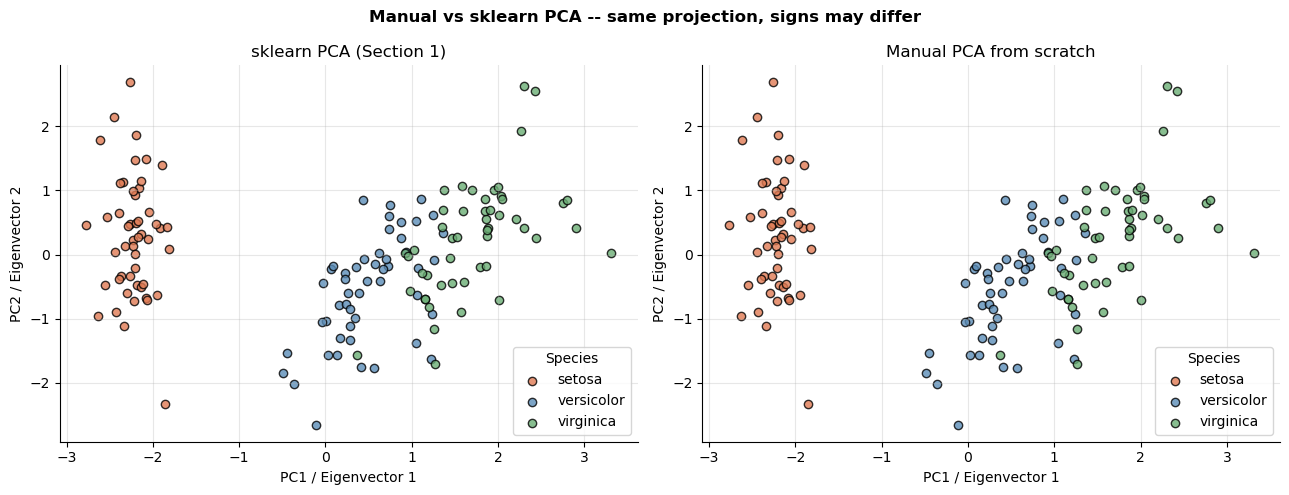

Note: eigenvector signs can flip. The shape is what matters, not the axis direction.


In [29]:
# Reproduce PCA manually. Fill in each step.

# Step 1: Centre the data by subtracting the mean of each feature.
# X_iris_scaled.mean(axis=0) gives the mean of each column.
X_centered = X_iris_scaled - X_iris_scaled.mean(axis=0)

# Step 2: Compute the covariance matrix.
# Pass X_centered.T so that variables are rows.
cov = np.cov(X_centered.T)
print("Covariance matrix shape:", cov.shape)

# Step 3: Eigendecomposition.
# Use np.linalg.eigh() which is designed for symmetric matrices.
eig_vals, eig_vecs = np.linalg.eigh(cov)

# Step 4: Sort from largest eigenvalue to smallest.
# np.argsort returns ascending indices; [::-1] reverses to descending.
order    = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[order]
eig_vecs = eig_vecs[:, order]
print("Eigenvalues:", eig_vals.round(4))

# Step 5: Project X_centered onto the top 2 eigenvectors.
# Use matrix multiplication (@). Result shape: (150, 2).
X_manual = X_centered @ eig_vecs[:,:2]

# Sign correction -- pre-filled, no need to change.
# Eigenvectors can flip sign; this aligns the manual result with sklearn's convention.
if X_manual[y_iris == 0, 0].mean() > 0:
    X_manual[:, 0] *= -1

# Side-by-side comparison -- pre-filled.
# If your steps above are correct, the two plots should look the same.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["#E07B54", "#5B8DB8", "#6BAE75"]

for cid, cname in enumerate(iris.target_names):
    mask = y_iris == cid
    axes[0].scatter(X_iris_pca[mask, 0], X_iris_pca[mask, 1],
                    color=colors[cid], label=cname, edgecolor="k", alpha=0.8)
    axes[1].scatter(X_manual[mask, 0], X_manual[mask, 1],
                    color=colors[cid], label=cname, edgecolor="k", alpha=0.8)

axes[0].set_title("sklearn PCA (Section 1)")
axes[1].set_title("Manual PCA from scratch")
for ax in axes:
    ax.set_xlabel("PC1 / Eigenvector 1")
    ax.set_ylabel("PC2 / Eigenvector 2")
    ax.legend(title="Species")
    ax.grid(True, alpha=0.3)

plt.suptitle("Manual vs sklearn PCA -- same projection, signs may differ",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("Note: eigenvector signs can flip. The shape is what matters, not the axis direction.")

---
## Exit Questions

Answer these after completing the lab. Write 2 to 4 sentences per answer.

**Q1. Why do we fit PCA with all components first before choosing how many to keep?**

Your answer:
>At the initial stage, we apply PCA using all components in order to determine the contribution of each principal component. 
It will help us determine the cumulative variance explained by principal components and establish the minimal number of principal components that can preserve most of the data.

---

**Q2. In Wine, PC1+PC2 captures only about 55% of variance but still separates the three wine classes clearly. What does this tell you?**

Your answer:
>This demonstrates that the directions which contain the maximum class-discriminating information can still occur even without containing all the variance of the data set. 
The lesser explained variance ratio does not necessarily indicate bad class discrimination since the critical discriminating factors between classes may already be captured by the first principal components.

---

**Q3. In the Digits reconstruction grid, what happens as d increases? Why?**

Your answer:
>The more components (d), the clearer the reconstructed image and closer to the original digit becomes. 
This is due to more principal components holding more information about the original data, thereby resulting in less reconstruction error.

---

**Q4. Why is PCA called unsupervised even though we coloured the Iris and Wine plots using class labels?**

Your answer:
>PCA is an unsupervised learning approach since the classification labels are not involved in the computation of the principal components. 
Only after computing the principal components was the data labeled and plotted to aid in understanding the visualization results.

---

**Q5. Name one situation where PCA would not be a good idea.**

Your answer:
>In cases where there are non-linear relationships within the data, PCA might not be the best method. 
As the name suggests, principal component analysis is only capable of capturing linear relationships; thus, it cannot conserve important information within the data set.


---
## Functions and Attributes Used in This Lab

Every function and attribute used today, grouped by library. Syntax, key parameters, and a link to official docs.

---

### numpy

**np.cumsum()**
```python
np.cumsum(
    a,        # input array
    axis=None # axis to accumulate along; None flattens first
)
# Returns cumulative sums. Used to track total variance added by each PC.
```
https://numpy.org/doc/stable/reference/generated/numpy.cumsum.html

---

**np.argsort()**
```python
np.argsort(
    a,       # input array
    axis=-1  # axis to sort along
)[::-1]      # [::-1] reverses to get descending order
# Returns indices that sort the array. Used in manual PCA to rank eigenvalues largest to smallest.
```
https://numpy.org/doc/stable/reference/generated/numpy.argsort.html

---

**np.cov()**
```python
np.cov(
    m,           # 2D array -- pass X.T so rows are variables
    rowvar=True  # if True (default) each row is one variable
)
# Returns the covariance matrix. Used in manual PCA (Section 5).
```
https://numpy.org/doc/stable/reference/generated/numpy.cov.html

---

**np.linalg.eigh()**
```python
np.linalg.eigh(
    a  # symmetric matrix -- covariance matrices are always symmetric
)
# Returns (eigenvalues, eigenvectors). Eigenvalues come in ascending order -- sort descending after.
# More numerically stable than eig() for symmetric matrices.
```
https://numpy.org/doc/stable/reference/generated/numpy.linalg.eigh.html

---

**np.where()**
```python
np.where(condition)[0]
# condition: boolean array, e.g. y == 0
# Returns indices where condition is True.
# Used to find the first image index of a given digit class.
```
https://numpy.org/doc/stable/reference/generated/numpy.where.html

---

### pandas

**pd.DataFrame()**
```python
pd.DataFrame(
    data,        # 2D numpy array or dict
    columns=None # list of column name strings
)
# Wraps a numpy array into a labelled table.
```
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html

---

**DataFrame.describe()**
```python
df.describe(
    include=None  # None = numeric columns only; "all" = every column
)
# Returns count, mean, std, min, quartiles, max for each column.
```
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html

---

**DataFrame.to_string()**
```python
df.to_string(
    index=True  # set False for cleaner printed output
)
# Renders the DataFrame as plain text. Useful inside print().
```
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_string.html

---

### sklearn.preprocessing

**StandardScaler()**
```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Subtracts the mean and divides by the standard deviation for each feature.
# fit_transform() = fit() + transform() in one step.
# Must be done before PCA so no feature dominates due to larger units or range.
```
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

---

### sklearn.decomposition

**PCA()**
```python
from sklearn.decomposition import PCA

pca = PCA(
    n_components=None,  # None = keep all components
                        # int  = exact number to keep
                        # float between 0 and 1 = keep enough to reach that variance fraction
    random_state=None   # seed for reproducibility
)
```
https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

**PCA.fit_transform(X)**
```python
pca.fit_transform(X)
# Fits PCA on X and returns projected coordinates in one call.
# Output shape: (n_samples, n_components)
```

**PCA.transform(X)**
```python
pca.transform(X)
# Projects new data into the PCA space already learned by fit().
# Use fit() on training data, then transform() on any subset.
```

**PCA.inverse_transform(X_projected)**
```python
pca.inverse_transform(X_projected)
# Maps data from PCA space back to original feature space.
# Reconstruction is approximate when n_components < total features.
```

**PCA.explained_variance_ratio_**
```python
pca.explained_variance_ratio_
# Attribute -- array of length n_components.
# Each value is the fraction of total variance explained by that component.
# np.cumsum(pca.explained_variance_ratio_) gives the running total.
```

---

### sklearn.datasets

**load_iris() / load_wine() / load_digits()**
```python
from sklearn.datasets import load_iris, load_wine, load_digits

ds = load_iris()        # same pattern for load_wine() and load_digits()
ds.data                 # numpy array, shape (n_samples, n_features)
ds.target               # numpy array of integer labels, shape (n_samples,)
ds.feature_names        # list of feature name strings
ds.target_names         # list of class name strings
# load_digits() also has: ds.images -- shape (1797, 8, 8)
```
https://scikit-learn.org/stable/datasets.html

---

### matplotlib

**plt.subplots()**
```python
fig, axes = plt.subplots(
    nrows=1,       # number of subplot rows
    ncols=1,       # number of subplot columns
    figsize=None   # (width, height) in inches
)
# axes[i]       -- single row of subplots
# axes[row, col] -- grid of subplots
```
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html

**ax.scatter()**
```python
ax.scatter(
    x, y,
    color=None,      # point colour
    label=None,      # legend label for this series
    edgecolor=None,  # border colour of each marker
    alpha=1.0        # opacity from 0 (invisible) to 1 (solid)
)
```

**ax.bar()**
```python
ax.bar(
    x,          # category labels or x positions
    height,     # bar heights
    color=None, # list of colours, one per bar
    edgecolor=None
)
```

**ax.plot()**
```python
ax.plot(
    x, y,
    marker=None,   # point marker, e.g. "o"
    color=None,
    linewidth=1.5,
    label=None
)
# Used to draw the cumulative variance line.
```

**ax.axhline() / ax.axvline()**
```python
ax.axhline(
    y,              # y value for the horizontal reference line
    color=None,
    linestyle="--", # "-", "--", "-.", ":"
    alpha=1.0,
    label=None
)
ax.axvline(x, ...)  # same parameters, draws a vertical line
```

**ax.twinx()**
```python
ax2 = ax1.twinx()
# Creates a second y-axis sharing the same x-axis.
# Used to overlay the cumulative variance line on the bar chart with its own y scale.
```

**ax.imshow()**
```python
ax.imshow(
    X,         # 2D array for grayscale; 3D for RGB
    cmap=None  # colourmap -- use "gray" for digit images
)
# Displays an image. Used in Section 3 to show 8x8 digit images.
```

**plt.suptitle()**
```python
plt.suptitle(
    t,             # title string
    fontsize=None,
    fontweight=None,
    y=None         # vertical position; raise above 1.0 to clear subplots
)
# Single title across the whole figure, above all subplots.
```
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.suptitle.html

---

### More documentation

| Library | Link |
|---|---|
| numpy full reference | https://numpy.org/doc/stable/reference/ |
| pandas full reference | https://pandas.pydata.org/docs/reference/index.html |
| sklearn decomposition | https://scikit-learn.org/stable/modules/classes.html#module-sklearn.decomposition |
| sklearn all datasets | https://scikit-learn.org/stable/datasets.html |
| matplotlib pyplot | https://matplotlib.org/stable/api/pyplot_summary.html |
